In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
match_df = pd.read_csv("C:\Pro\Data Analysis\Python\IPL_Data_Analysis_Python\data\RCB_vs_DC_April_10.csv")

print(match_df.head())


<>:5: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rkarj\AppData\Local\Temp\ipykernel_20336\2466986467.py:5: SyntaxWarning: invalid escape sequence '\P'
  match_df = pd.read_csv("C:\Pro\Data Analysis\Python\IPL_Data_Analysis_Python\data\RCB_vs_DC_April_10.csv")


                          team  over   batter    bowler non_striker  \
0  Royal Challengers Bengaluru     0  PD Salt  MA Starc     V Kohli   
1  Royal Challengers Bengaluru     0  PD Salt  MA Starc     V Kohli   
2  Royal Challengers Bengaluru     0  PD Salt  MA Starc     V Kohli   
3  Royal Challengers Bengaluru     0  PD Salt  MA Starc     V Kohli   
4  Royal Challengers Bengaluru     0  V Kohli  MA Starc     PD Salt   

   runs_batter  runs_extras  runs_total extras_type wicket_kind player_out  \
0            0            0           0         NaN         NaN        NaN   
1            0            0           0         NaN         NaN        NaN   
2            0            5           5       wides         NaN        NaN   
3            1            0           1         NaN         NaN        NaN   
4            1            0           1         NaN         NaN        NaN   

  fielders  
0      NaN  
1      NaN  
2      NaN  
3      NaN  
4      NaN  


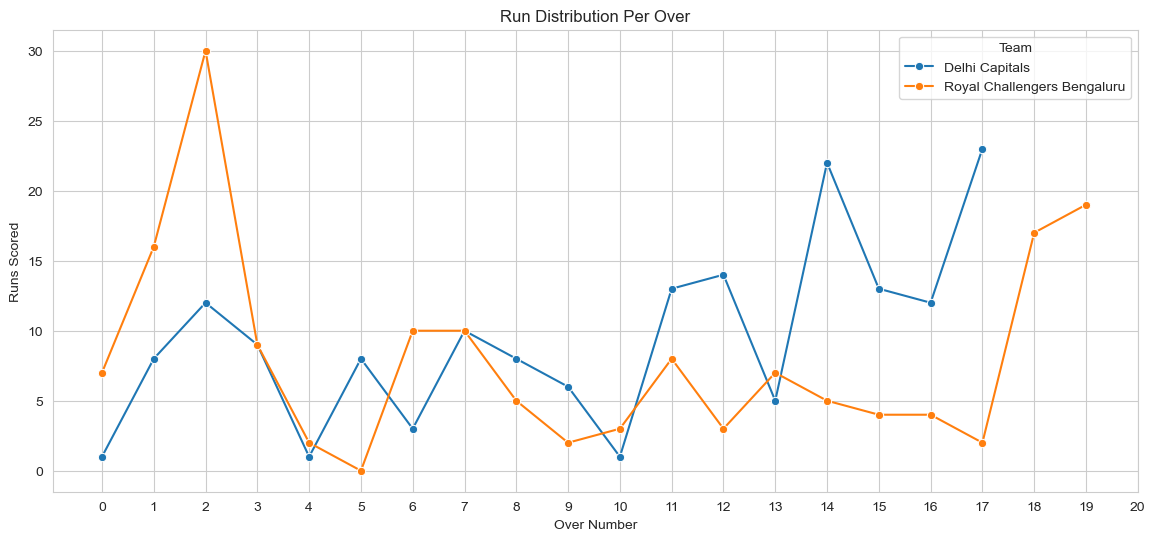

In [2]:
# Run distribution per over
sns.set_style("whitegrid")

# data preparation for run distribution per over
run_distribution = match_df.groupby(['team', 'over']).agg({'runs_total': 'sum'}).reset_index()

# plotting run distribution per over for both teams
plt.figure(figsize=(14, 6))
sns.lineplot(data=run_distribution, x='over', y='runs_total', hue='team', marker='o')
plt.title('Run Distribution Per Over')
plt.xlabel('Over Number')
plt.ylabel('Runs Scored')
plt.xticks(range(0, 21))  # over numbers from 0 to 20
plt.legend(title='Team')

plt.savefig('run_distribution_RCB_vs_DC.png', dpi=300, bbox_inches='tight')
plt.show()

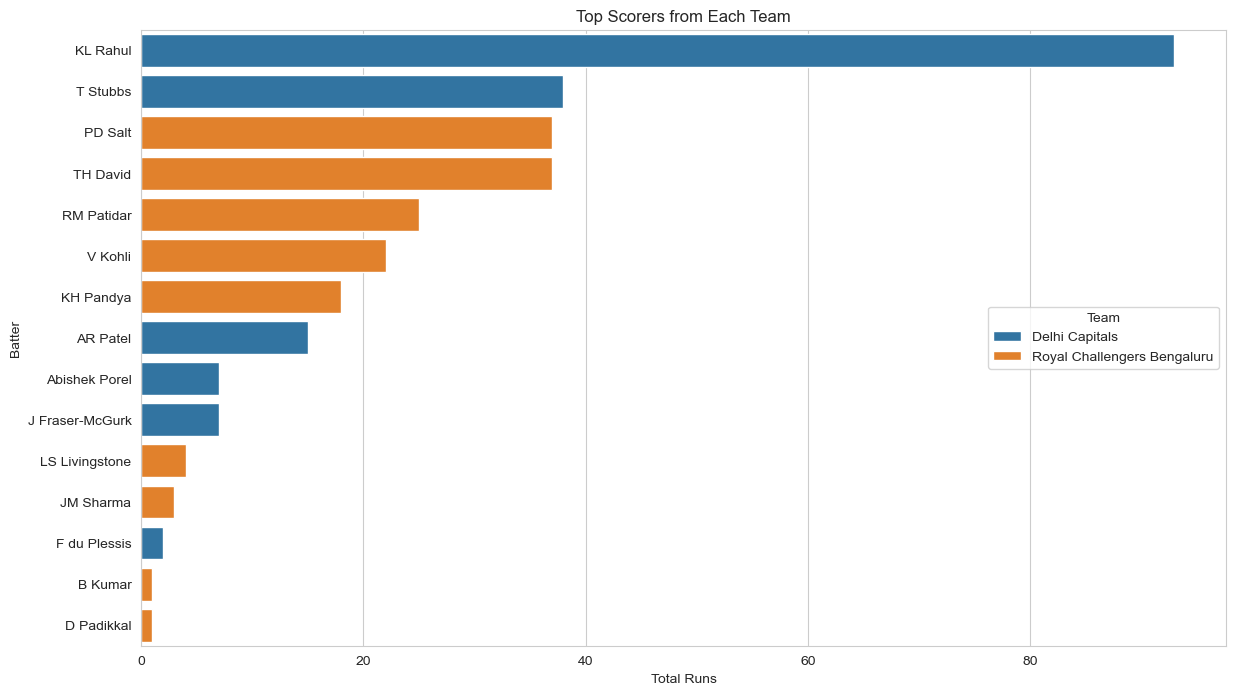

In [3]:
# Batsman Contribution
top_scorers = match_df.groupby(['team', 'batter']).agg({'runs_batter': 'sum'}).reset_index().sort_values(by='runs_batter', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_scorers, x='runs_batter', y='batter', hue='team', dodge=False)
plt.title('Top Scorers from Each Team')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.legend(title='Team', loc='center right')

plt.savefig('top_scorers_RCB_vs_DC.png', dpi=300, bbox_inches='tight')
plt.show()

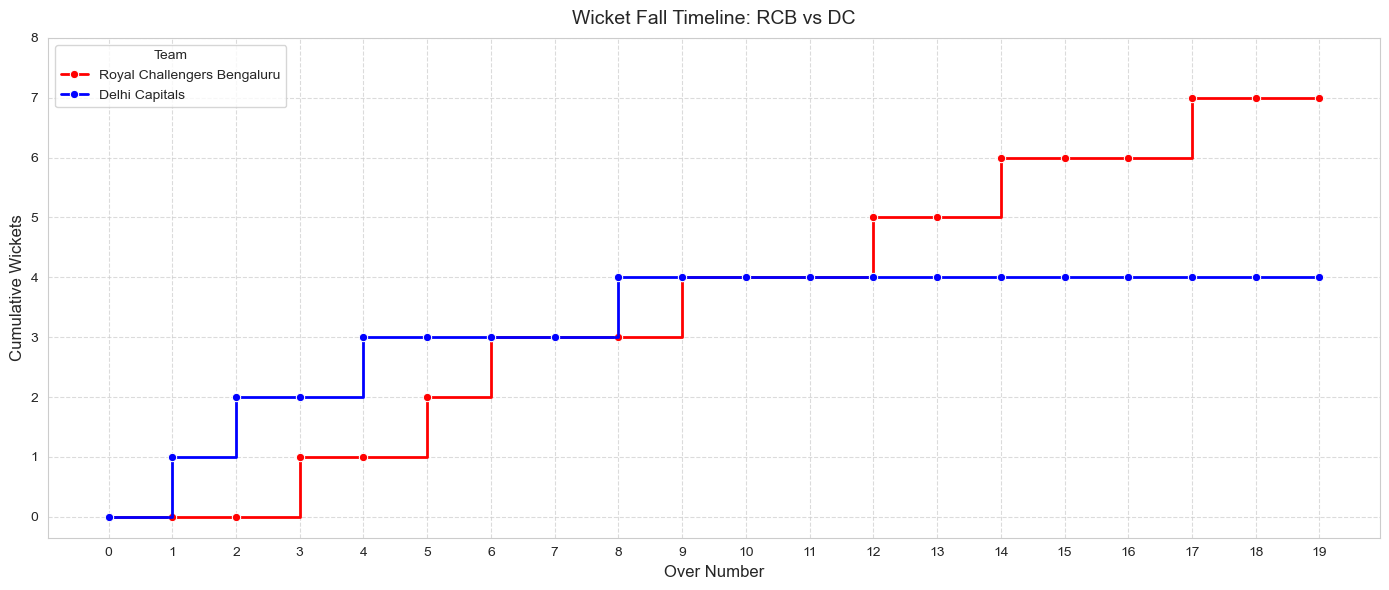

In [4]:
# Wicket Fall Timeline

sns.set_style("whitegrid")


# Filter wicket events (where wicket_kind is not empty)
wicket_data = match_df[match_df['wicket_kind'].notna()]

# Group by team and over to count wickets per over
wicket_counts = wicket_data.groupby(['team', 'over']).size().reset_index(name='wickets')

# Create a complete range of overs (0 to 19) for both teams to ensure all overs are represented
teams = ['Royal Challengers Bengaluru', 'Delhi Capitals']
overs = range(20)
full_overs = pd.MultiIndex.from_product([teams, overs], names=['team', 'over']).to_frame(index=False)

# Merge with wicket counts, filling missing overs with 0 wickets
wicket_counts = full_overs.merge(wicket_counts, on=['team', 'over'], how='left').fillna({'wickets': 0})

# Calculate cumulative wickets for each team
wicket_counts['cumulative_wickets'] = wicket_counts.groupby('team')['wickets'].cumsum()

# Plotting wicket fall timeline for both teams
plt.figure(figsize=(14, 6))
sns.lineplot(data=wicket_counts, x='over', y='cumulative_wickets', hue='team', drawstyle='steps-post',
             marker='o', linewidth=2, palette={'Royal Challengers Bengaluru': 'red', 'Delhi Capitals': 'blue'})
plt.title('Wicket Fall Timeline: RCB vs DC', fontsize=14, pad=10)
plt.xlabel('Over Number', fontsize=12)
plt.ylabel('Cumulative Wickets', fontsize=12)
plt.xticks(range(0, 20))  # Over numbers from 0 to 19
plt.yticks(range(0, int(wicket_counts['cumulative_wickets'].max()) + 2))  # Dynamic y-axis ticks
plt.legend(title='Team', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig('wicket_fall_timeline_rcb_vs_dc.png', dpi=300, bbox_inches='tight')
plt.show()

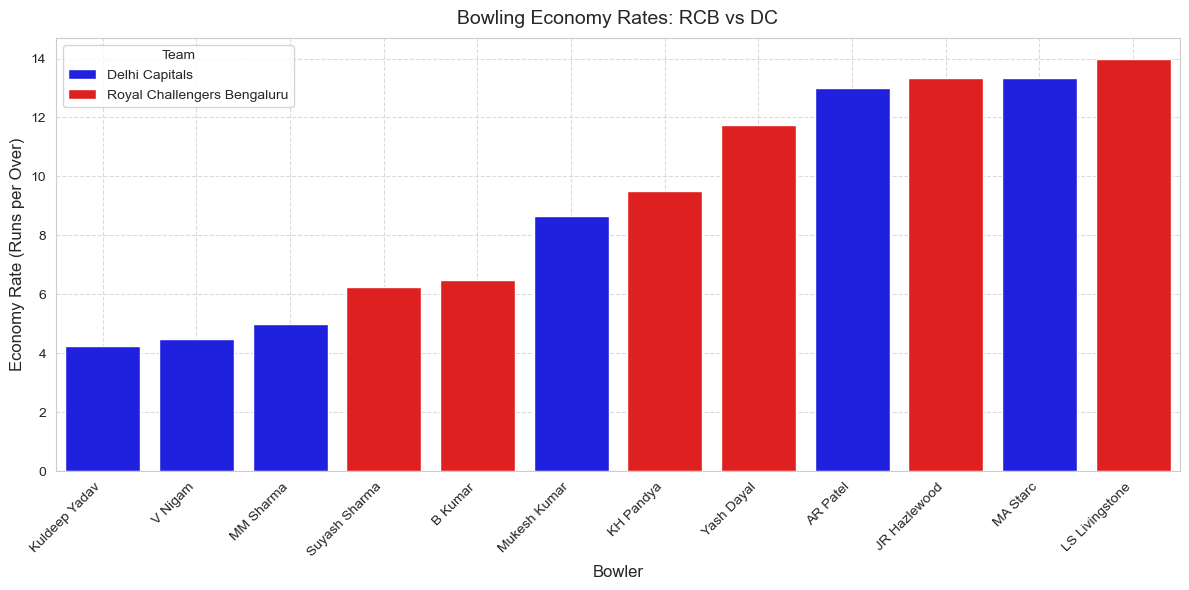

In [5]:
# Bowling economy rate

sns.set_style("whitegrid")

# Data preparation for bowling economy rate
# Calculate runs conceded by each bowler
runs_conceded = match_df.groupby(['bowler', 'team'])['runs_total'].sum().reset_index()

# Count valid balls bowled (excluding wides and no-balls)
valid_balls = match_df[~match_df['extras_type'].isin(['wides', 'noballs'])]
balls_bowled = valid_balls.groupby(['bowler', 'team']).size().reset_index(name='balls')

# Merge runs and balls data
bowling_stats = runs_conceded.merge(balls_bowled, on=['bowler', 'team'], how='inner')

# Calculate overs bowled (balls / 6) and economy rate (runs / overs)
bowling_stats['overs'] = bowling_stats['balls'] / 6
bowling_stats['economy_rate'] = bowling_stats['runs_total'] / bowling_stats['overs']

# Filter bowlers with at least 1 over bowled for meaningful analysis
bowling_stats = bowling_stats[bowling_stats['overs'] >= 1]

# Sort by economy rate for better visualization
bowling_stats = bowling_stats.sort_values('economy_rate')

# Create a team indicator for coloring (RCB vs DC bowlers)
bowling_stats['team_color'] = bowling_stats['team'].apply(
    lambda x: 'Royal Challengers Bengaluru' if x == 'Delhi Capitals' else 'Delhi Capitals'
)

# Plotting bowling economy rate
plt.figure(figsize=(12, 6))
sns.barplot(data=bowling_stats, x='bowler', y='economy_rate', hue='team_color',
            palette={'Royal Challengers Bengaluru': 'red', 'Delhi Capitals': 'blue'})
plt.title('Bowling Economy Rates: RCB vs DC', fontsize=14, pad=10)
plt.xlabel('Bowler', fontsize=12)
plt.ylabel('Economy Rate (Runs per Over)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Team', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig('bowling_economy_rate_rcb_vs_dc.png', dpi=300, bbox_inches='tight')
plt.show()

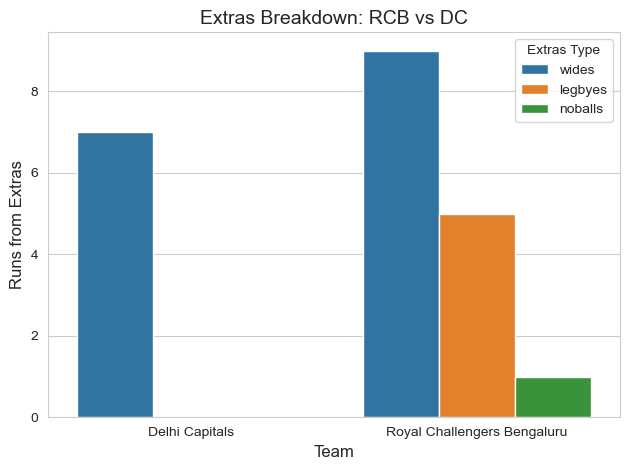

In [6]:
# Extras Breakdown

sns.set_style("whitegrid")

# Data preparation for extras breakdown
# Filter rows where extras_type is not empty
extras_data = match_df[match_df['extras_type'].notna() & (match_df['extras_type'] != '')]

# Group by team and extras_type to sum runs_extras
extras_summary = extras_data.groupby(['team', 'extras_type'])['runs_extras'].sum().reset_index()

# Pivot the data to get extras_type as columns for each team
extras_pivot = extras_summary.pivot(index='team', columns='extras_type', values='runs_extras').fillna(0)

# Instead of using extras_pivot, use extras_summary directly for the bar plot
# with 'extras_type' as the hue
sns.barplot(data=extras_summary, y='runs_extras', x='team', hue='extras_type') # Changed this line

plt.title('Extras Breakdown: RCB vs DC', fontsize=14)
plt.xlabel('Team', fontsize=12)
plt.xticks(rotation = 0)
plt.ylabel('Runs from Extras', fontsize=12)
plt.legend(title='Extras Type')
plt.tight_layout()
plt.savefig('extras_breakdown_bar_rcb_vs_dc.png', dpi=300, bbox_inches='tight')
plt.show()

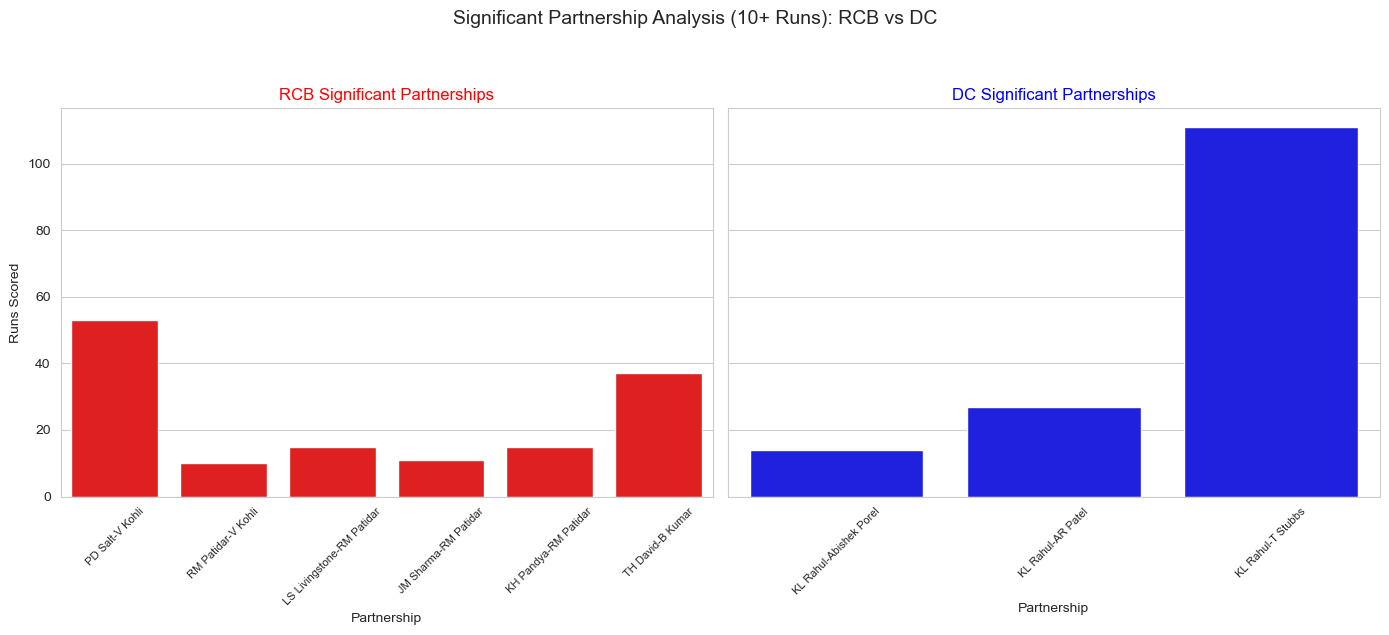

In [7]:
# Partnership Analysis

sns.set_style("whitegrid")

# Function to calculate partnerships for a team
def calculate_partnerships(team_data):
    partnerships = []
    current_partnership = {'batter': None, 'non_striker': None, 'runs': 0, 'balls': 0, 'wicket_no': 0}
    wicket_count = 0

    for i, row in team_data.sort_values(['over', 'batter']).iterrows():
        batter = row['batter']
        non_striker = row['non_striker']
        runs = row['runs_total']

        # Initialize or continue partnership
        if current_partnership['batter'] is None:
            current_partnership['batter'] = batter
            current_partnership['non_striker'] = non_striker
            current_partnership['wicket_no'] = wicket_count + 1

        # Check if partnership changes (due to wicket or batting order change)
        if (batter not in [current_partnership['batter'], current_partnership['non_striker']] or
            non_striker not in [current_partnership['batter'], current_partnership['non_striker']]):
            if current_partnership['runs'] >= 10:  # Only include partnerships with 10+ runs
                partnerships.append(current_partnership.copy())
            current_partnership = {'batter': batter, 'non_striker': non_striker, 'runs': 0, 'balls': 0, 'wicket_no': wicket_count + 1}

        # Add runs and increment balls
        current_partnership['runs'] += runs
        current_partnership['balls'] += 1 if row['extras_type'] not in ['wides', 'noballs'] else 0

        # Handle wicket event
        if pd.notna(row['wicket_kind']):
            if current_partnership['runs'] >= 10:  # Save significant partnership before resetting
                partnerships.append(current_partnership.copy())
            wicket_count += 1
            current_partnership = {'batter': None, 'non_striker': None, 'runs': 0, 'balls': 0, 'wicket_no': wicket_count + 1}

    # Append the last partnership if it has 10+ runs
    if current_partnership['runs'] >= 10:
        partnerships.append(current_partnership)

    return pd.DataFrame(partnerships)

# Filter data for each team
rcb_data = match_df[match_df['team'] == 'Royal Challengers Bengaluru']
dc_data = match_df[match_df['team'] == 'Delhi Capitals']

# Calculate partnerships for both teams
rcb_partnerships = calculate_partnerships(rcb_data)
dc_partnerships = calculate_partnerships(dc_data)

# Handle case where no significant partnerships exist
if rcb_partnerships.empty and dc_partnerships.empty:
    print("No partnerships with 10+ runs found for either team.")
else:
    # Create partnership labels (e.g., "Kohli-Salt")
    rcb_partnerships['label'] = rcb_partnerships['batter'] + '-' + rcb_partnerships['non_striker']
    dc_partnerships['label'] = dc_partnerships['batter'] + '-' + dc_partnerships['non_striker']

    # Plotting partnership analysis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # RCB Partnerships
    if not rcb_partnerships.empty:
        sns.barplot(data=rcb_partnerships, x='label', y='runs', ax=ax1, color='red')
    else:
        ax1.text(0.5, 0.5, 'No significant partnerships (10+ runs)',
                 ha='center', va='center', fontsize=10, color='red')
        ax1.set_xticks([])
    ax1.set_title('RCB Significant Partnerships', fontsize=12, color='red')
    ax1.set_xlabel('Partnership', fontsize=10)
    ax1.set_ylabel('Runs Scored', fontsize=10)
    ax1.tick_params(axis='x', rotation=45, labelsize=8)

    # DC Partnerships
    if not dc_partnerships.empty:
        sns.barplot(data=dc_partnerships, x='label', y='runs', ax=ax2, color='blue')
    else:
        ax2.text(0.5, 0.5, 'No significant partnerships (10+ runs)',
                 ha='center', va='center', fontsize=10, color='blue')
        ax2.set_xticks([])
    ax2.set_title('DC Significant Partnerships', fontsize=12, color='blue')
    ax2.set_xlabel('Partnership', fontsize=10)
    ax2.tick_params(axis='x', rotation=45, labelsize=8)

    # Adjust layout and add main title
    plt.suptitle('Significant Partnership Analysis (10+ Runs): RCB vs DC', fontsize=14, y=1.05)
    plt.tight_layout()

    # Save the plot
    plt.savefig('partnership_analysis_significant_rcb_vs_dc.png', dpi=300, bbox_inches='tight')
    plt.show()

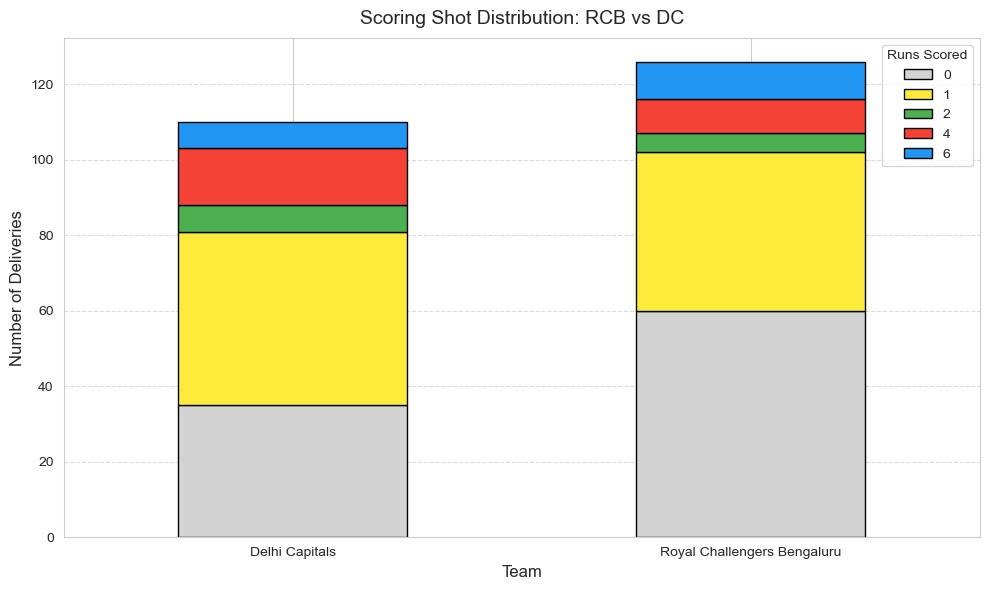

In [8]:
# Scoring Shot Distribution

sns.set_style("whitegrid")

# Data preparation for scoring shot distribution
# Filter for batter runs only (exclude extras)
scoring_data = match_df[['team', 'runs_batter']].copy()

# Group by team and runs_batter to count occurrences
run_counts = scoring_data.groupby(['team', 'runs_batter']).size().reset_index(name='count')

# Pivot to get run types as columns
run_pivot = run_counts.pivot(index='team', columns='runs_batter', values='count').fillna(0)

# Ensure all possible run types (0, 1, 2, 4, 6) are included
for run in [0, 1, 2, 4, 6]:
    if run not in run_pivot.columns:
        run_pivot[run] = 0

# Rename columns for clarity
run_pivot.columns = [f'{int(col)}' for col in run_pivot.columns]

# Reorder columns to ensure consistent display
run_pivot = run_pivot[['0', '1', '2', '4', '6']]

# Plotting scoring shot distribution as a stacked bar plot
plt.figure(figsize=(10, 6))
run_pivot.plot(kind='bar', stacked=True,
               color=['#d3d3d3', '#ffeb3b', '#4caf50', '#f44336', '#2196f3'],  # Colors for 0, 1, 2, 4, 6
               edgecolor='black', ax=plt.gca())
plt.title('Scoring Shot Distribution: RCB vs DC', fontsize=14, pad=10)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Deliveries', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title='Runs Scored', fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()

# Save the plot
plt.savefig('scoring_shot_distribution_rcb_vs_dc.png', dpi=300, bbox_inches='tight')
plt.show()